Memuat data asli ke memori...
-> Membaca Mentah: 40 gambar
-> Membaca Setengah Matang: 40 gambar
-> Membaca Matang: 40 gambar
Melakukan augmentasi pada 96 data latih...
Total data latih setelah augmentasi: 480

HASIL TRAINING MURNI (ANTI-LEAKAGE)
Akurasi Final: 75.00%

Laporan Metrik:
                 precision    recall  f1-score   support

         Mentah       0.83      0.62      0.71         8
Setengah Matang       0.62      1.00      0.76         8
         Matang       1.00      0.62      0.77         8

       accuracy                           0.75        24
      macro avg       0.82      0.75      0.75        24
   weighted avg       0.82      0.75      0.75        24



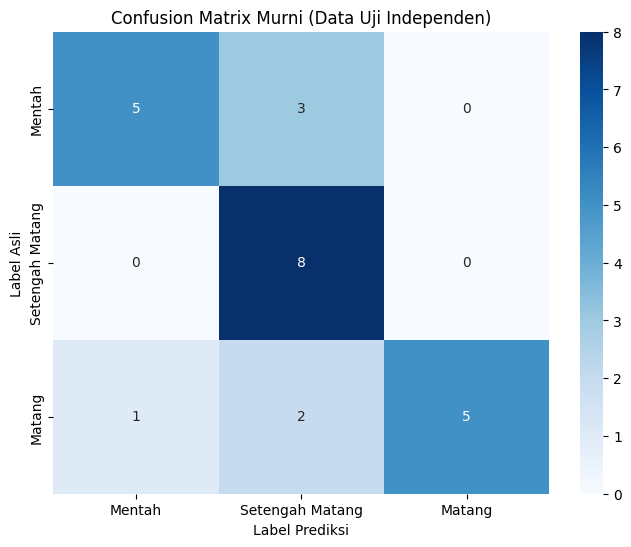

In [ ]:
import os
import cv2
import zipfile
import shutil
import glob
import numpy as np
from google.colab import files
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array

# deteksi zip
zip_files = glob.glob('*.zip')

if not zip_files:
    raise FileNotFoundError("file zip tidak ditemukan")

zip_path = zip_files[0] # mengambil file zip pertama yang ditemukan
print(f"deteksi file zip: {zip_path}")

extract_path = '/content/Dataset_Asli'

# ekstrak file zip
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print("berhasil mengekstrak file zip.")

output_dir = '/content/Dataset Preprocessing'
classes = ['Mentah', 'Setengah Matang', 'Matang']
target_size = (224, 224)

# buat folder output
for cls in classes:
    os.makedirs(os.path.join(output_dir, cls), exist_ok=True)

# inisialisasi augmentasi rotasi -+ sampai 20 derajat dan flip
datagen = ImageDataGenerator(
    rotation_range=20,
    horizontal_flip=True,
    fill_mode='nearest'
)

print("proses preprocessing & augmentasi")

# proses per kelas
for cls in classes:
    # memcari folder kelas di dalam hasil ekstrak
    class_path = ""
    for root, dirs, files_in_dir in os.walk(extract_path):
        # mencek dengan case insensitive agar lebih aman
        dirs_lower = [d.lower() for d in dirs]
        if cls.lower() in dirs_lower:
            # mengambil nama folder asli sesuai yang terdeteksi
            actual_dir_name = dirs[dirs_lower.index(cls.lower())]
            class_path = os.path.join(root, actual_dir_name)
            break

    if not class_path:
        print(f"folder kelas '{cls}' tidak ditemukan di dalam zip")
        continue

    output_class_path = os.path.join(output_dir, cls)
    img_names = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    print(f"memproses {cls}: {len(img_names)} gambar asli")

    for img_name in img_names:
        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path)
        if img is None: continue

        # resize rgb
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img, target_size)

        # menyimpan gambar hasil resize
        base_name = os.path.splitext(img_name)[0]
        cv2.imwrite(os.path.join(output_class_path, f"{base_name}_std.jpg"), cv2.cvtColor(img_resized, cv2.COLOR_RGB2BGR))

        # augmentasi 2 variasi baru per gambar
        img_array = img_to_array(img_resized)
        img_array = img_array.reshape((1,) + img_array.shape)

        aug_iter = datagen.flow(img_array, batch_size=1, save_to_dir=output_class_path,
                                save_prefix=f"{base_name}_aug", save_format='jpg')
        for _ in range(2):
            next(aug_iter)

print("preprocessing selesai")

# zownload zip hasil
print("sedang membuat file zip hasil akhir")
output_zip = 'Dataset Preprocessing'
shutil.make_archive(output_zip, 'zip', output_dir)

print(f"file {output_zip}zip telah dibuat, mendownload")
files.download(f'{output_zip}.zip')